# Решение заданий


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

## Загрузка и очистка даных

In [3]:
df = pd.read_csv("flights_NY.csv")
df.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762


In [5]:
data = df.dropna().copy()
print("Кол-во объектов до очистки", df.shape[0])
print("Кол-во объектов после очистки", data.shape[0])
data.head()

Кол-во объектов до очистки 336776
Кол-во объектов после очистки 327346


,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089
3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576
4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762


Была удалена небольшая часть данных (3%) что не должно повлиять на дольнейшую аналитику поэтому не будем заполнять данные с пропусками а просто выкинем их

In [38]:
data["speed_mph"] = data["distance"] / (data["air_time"] / 60)

Так же дополнительна посчитана скорость

# Задание 1

Группировка данных по авиакомпаниям с числом самолетов > 200 и подсчет процента задержанных рейсов

In [ ]:
carrier_stats = (
    data.groupby("carrier")
    .agg(
        n_planes=("tailnum", "nunique"),
        dep_delay_probability=("dep_delay", lambda x: (x > 0).mean()),
    )stats.norm.ppf([0.025, 0.975], loc = M, scale = S)
    .reset_index()
)

task1 = (
    carrier_stats[carrier_stats["n_planes"] > 200]
    .reset_index(drop=True)
)

task1["dep_delay_probability"] = (
    100 * task1["dep_delay_probability"]
).round(2)

task1_by_planes = (
    task1
    .sort_values("n_planes", ascending=False)
    .reset_index(drop=True)
)

task1_by_delay = (
    task1
    .sort_values("dep_delay_probability", ascending=False)
    .reset_index(drop=True)
)

task1_by_delay

,carrier,n_planes,dep_delay_probability
0,WN,581,54.26
1,UA,620,46.94
2,EV,316,44.96
3,9E,203,40.36
4,DL,626,31.86
5,MQ,237,31.82
6,AA,600,31.63
7,US,289,24.01


Отрисуем графики зависимости

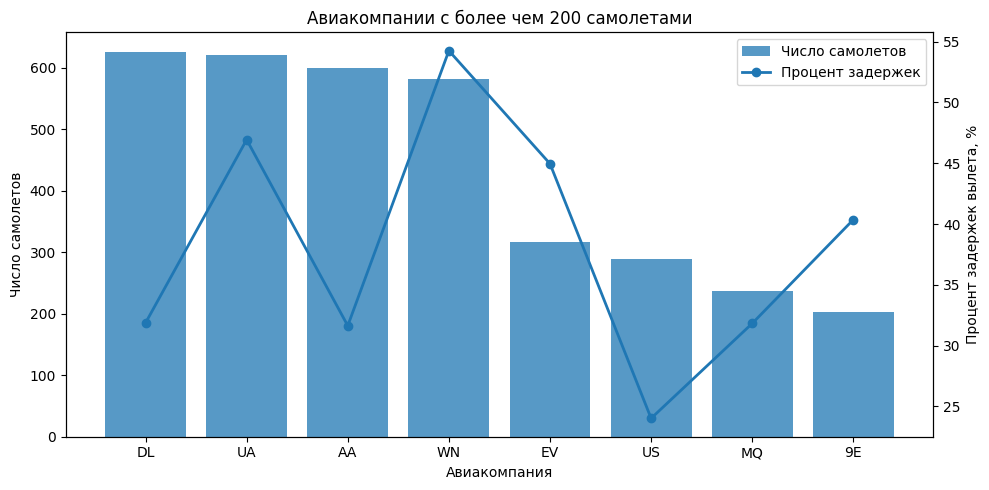

In [23]:
x = np.arange(len(task1_by_planes))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(x, task1_by_planes["n_planes"], alpha=0.75, label="Число самолетов")
ax1.set_xticks(x)
ax1.set_xticklabels(task1_by_planes["carrier"])
ax1.set_xlabel("Авиакомпания")
ax1.set_ylabel("Число самолетов")

ax2 = ax1.twinx()
ax2.plot(
    x,
    task1_by_planes["dep_delay_probability"],
    marker="o",
    linewidth=2,
    label="Процент задержек"
)
ax2.set_ylabel("Процент задержек вылета, %")

ax1.legend(
    ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0],
    ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1],
    loc="upper right"
)

plt.title("Авиакомпании с более чем 200 самолетами")
plt.tight_layout()
plt.show()

Наибольшая вероятность задержки у компании WN

# Задание 2

Посчитаем среднее время для каждого самолета в полете и оценим параметры нормального закона 

In [36]:
task2 = (
    data.groupby("tailnum")
    .agg(
        mean_air_time = ("air_time", "mean")
    )
    .reset_index()
)

mean_time = task2["mean_air_time"]
M = mean_time.mean()
S = mean_time.std()
q_l, q_h = mean_time.quantile([0.025, 0.975])

print(f"Среднее = {M}, Отклонение = {S}, квантили {q_l}, {q_h}")
task2

Среднее = 157.4966402284288, Отклонение = 75.80499806680461, квантили 58.86941031941032, 334.1267857142857


,tailnum,mean_air_time
0,D942DN,134.750000
1,N0EGMQ,103.823864
2,N10156,115.372414
3,N102UW,82.812500
4,N103US,83.347826
...,...,...
4032,N997DL,126.935484
4033,N998AT,92.920000
4034,N998DL,124.789474
4035,N999DN,130.327869


Теперь изобразим данные на графие

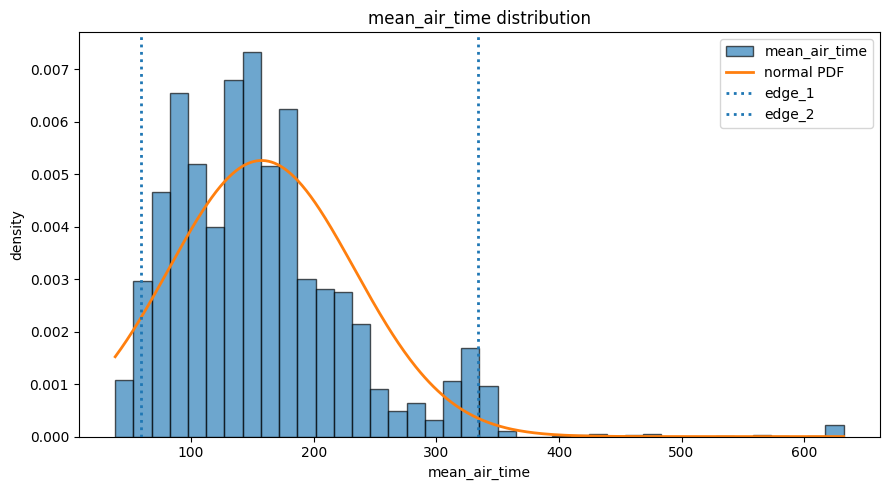

In [35]:
x = np.linspace(mean_time.min(), mean_time.max(), 500)
pdf = stats.norm.pdf(x, loc=M, scale=S)

plt.figure(figsize=(9, 5))

plt.hist(
    mean_time,
    bins=40,
    density=True,
    alpha=0.65,
    edgecolor="black",
    label="mean_air_time"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="normal PDF"
)

plt.axvline(q_l, linestyle=":", linewidth=2, label="edge_1")
plt.axvline(q_h, linestyle=":", linewidth=2, label="edge_2")

plt.xlabel("mean_air_time")
plt.ylabel("density")
plt.title("mean_air_time distribution")
plt.legend()
plt.tight_layout()
plt.show()

Среднее время полета для 95 процентов самолетов лежит в пределах от 58.9 минут до 334.1 минуты

# Задание 3

In [ ]:
task3 = (
    data[data["carrier"].isin(["WN", "UA"])]
    .groupby(["carrier", "tailnum"])
    .agg(
        mean_speed=("speed_mph", "mean")
    )
    .reset_index()
)

wn = task3.loc[task3["carrier"] == "WN", "mean_speed"]
ua = task3.loc[task3["carrier"] == "UA", "mean_speed"]

,carrier,tailnum,mean_speed
0,UA,N11206,412.708400
1,UA,N12109,430.457425
2,UA,N12114,425.138359
3,UA,N12116,420.426235
4,UA,N12125,421.103811
...,...,...,...
1196,WN,N965WN,407.466842
1197,WN,N966WN,392.563629
1198,WN,N967WN,404.759751
1199,WN,N968WN,415.177138


In [43]:
task3 = (
    data[data["carrier"].isin(["WN", "UA"])]
    .groupby(["carrier", "tailnum"])
    .agg(
        mean_speed=("speed_mph", "mean")
    )
    .reset_index()
)

wn = task3.loc[task3["carrier"] == "WN", "mean_speed"]
ua = task3.loc[task3["carrier"] == "UA", "mean_speed"]

def mean_interval(x):
    n = len(x)
    M = x.mean()
    S = x.std()
    edge = stats.t.ppf(0.975, n - 1) * S / np.sqrt(n)
    return M, M - edge, M + edge

wn_mean, wn_l, wn_h = mean_interval(wn)
ua_mean, ua_l, ua_h = mean_interval(ua)
print(f"Среднее значение и границы доверительного интервала для авиакомпании WN : {wn_mean}, {wn_l}, {wn_h}")
print(f"Среднее значение и границы доверительного интервала для авиакомпании UA : {ua_mean}, {ua_l}, {ua_h}")

task3

Среднее значение и границы доверительного интервала для авиакомпании WN : 397.6440259322983, 396.4754243386347, 398.8126275259619
Среднее значение и границы доверительного интервала для авиакомпании UA : 423.36629794324494, 421.9317464684589, 424.80084941803096


,carrier,tailnum,mean_speed
0,UA,N11206,412.708400
1,UA,N12109,430.457425
2,UA,N12114,425.138359
3,UA,N12116,420.426235
4,UA,N12125,421.103811
...,...,...,...
1196,WN,N965WN,407.466842
1197,WN,N966WN,392.563629
1198,WN,N967WN,404.759751
1199,WN,N968WN,415.177138


In [44]:
ttest = stats.ttest_ind(wn, ua, equal_var=False)
ks_test = stats.ks_2samp(wn, ua)

task3_tests = pd.DataFrame({
    "test": ["Welch t-test", "KS-test"],
    "statistic": [ttest.statistic, ks_test.statistic],
    "p_value": [ttest.pvalue, ks_test.pvalue],
})

task3_tests

,test,statistic,p_value
0,Welch t-test,-27.301769,2.792906e-127
1,KS-test,0.678674,4.126460e-132


На основе получившихся результатов можно сделать вывод, что скорости самолетов значимо отличаются друг от друга

Нарисуем графики

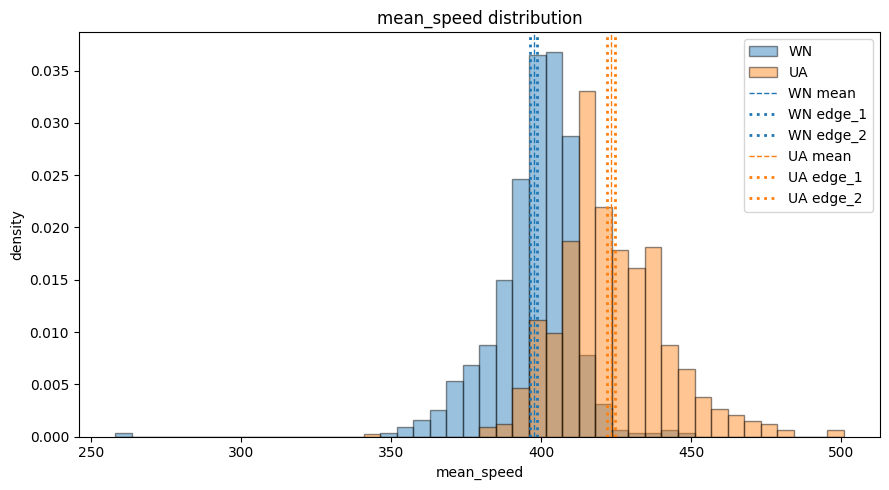

In [ ]:
colors = {
    "WN": "tab:blue",
    "UA": "tab:orange"
}

bins = np.linspace(
    min(wn.min(), ua.min()),
    max(wn.max(), ua.max()),
    45
)

plt.figure(figsize=(9, 5))

plt.hist(
    wn,
    bins=bins,
    density=True,
    alpha=0.45,
    edgecolor="black",
    label="WN",
    color=colors["WN"]
)

plt.hist(
    ua,
    bins=bins,
    density=True,
    alpha=0.45,
    edgecolor="black",
    label="UA",
    color=colors["UA"]
)

for _, row in task3_stats.iterrows():
    carrier = row["carrier"]
    
    plt.axvline(
        row["mean_speed"],
        linestyle="--",
        linewidth=1,
        color=colors[carrier],
        label=f"{carrier} mean"
    )
    
    plt.axvline(
        row["edge_1"],
        linestyle=":",ttest = stats.ttest_ind(wn, ua, equal_var=False)
ks_test = stats.ks_2samp(wn, ua)

task3_tests = pd.DataFrame({
    "test": ["Welch t-test", "KS-test"],
    "statistic": [ttest.statistic, ks_test.statistic],
    "p_value": [ttest.pvalue, ks_test.pvalue],
})

task3_tests
        linewidth=2,
        color=colors[carrier],
        label=f"{carrier} edge_1"
    )
    
    plt.axvline(
        row["edge_2"],
        linestyle=":",
        linewidth=2,
        color=colors[carrier],
        label=f"{carrier} edge_2"
    )

plt.xlabel("mean_speed")
plt.ylabel("density")
plt.title("mean_speed distribution")
plt.legend()
plt.tight_layout()
plt.show()

# Задание 4

In [51]:
task4 = (
    data.groupby("tailnum")
    .agg(
        mean_speed=("speed_mph", "mean"),
        mean_distance=("distance", "mean")
    )
    .reset_index()
)

task4

,tailnum,mean_speed,mean_distance
0,D942DN,381.463714,854.500000
1,N0EGMQ,390.577378,679.383523
2,N10156,385.115125,756.303448
3,N102UW,393.785127,535.875000
4,N103US,387.943443,535.195652
...,...,...,...
4032,N997DL,406.088350,866.435484
4033,N998AT,381.080602,586.800000
4034,N998DL,406.689181,854.684211
4035,N999DN,408.278021,895.459016


Подготовка данных для работы с линейной регрессией

In [99]:
X = task4[["mean_speed"]]
y = task4["mean_distance"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

/home/avgurmordra/miniconda3/envs/myenv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


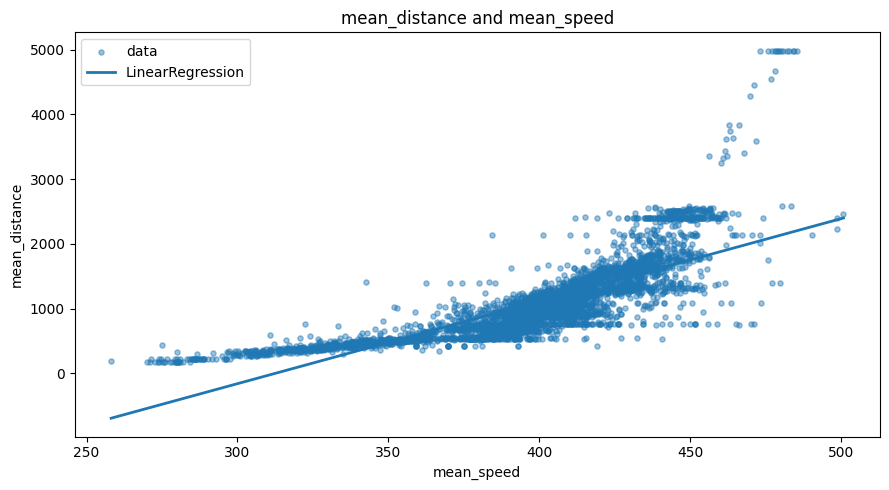

In [100]:
x = np.linspace(
    task4["mean_speed"].min(),
    task4["mean_speed"].max(),
    500
).reshape(-1, 1)

y_pred = model.predict(x)

plt.figure(figsize=(9, 5))

plt.scatter(
    task4["mean_speed"],
    task4["mean_distance"],
    alpha=0.45,
    s=14,
    label="data"
)

plt.plot(
    x.ravel(),
    y_pred,
    linewidth=2,
    label="LinearRegression"
)

plt.xlabel("mean_speed")
plt.ylabel("mean_distance")
plt.title("mean_distance and mean_speed")
plt.legend()
plt.tight_layout()
plt.show()

Наша зависимость сильно отличается от исходных данных по этой причине попробуем воспользоваться полиномиальными признаками

In [108]:
task4["mean_speed_2"] = task4["mean_speed"] ** 2
task4["mean_speed_3"] = task4["mean_speed"] ** 3


X = task4[["mean_speed", "mean_speed_2", "mean_speed_3"]]
y = task4["mean_distance"]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

In [109]:
x = np.linspace(
    task4["mean_speed"].min(),
    task4["mean_speed"].max(),
    500
)

x_plot = pd.DataFrame({
    "mean_speed": x,
    "mean_speed_2": x ** 2,
    "mean_speed_3": x ** 3,
})

y_plot = model.predict(x_plot)

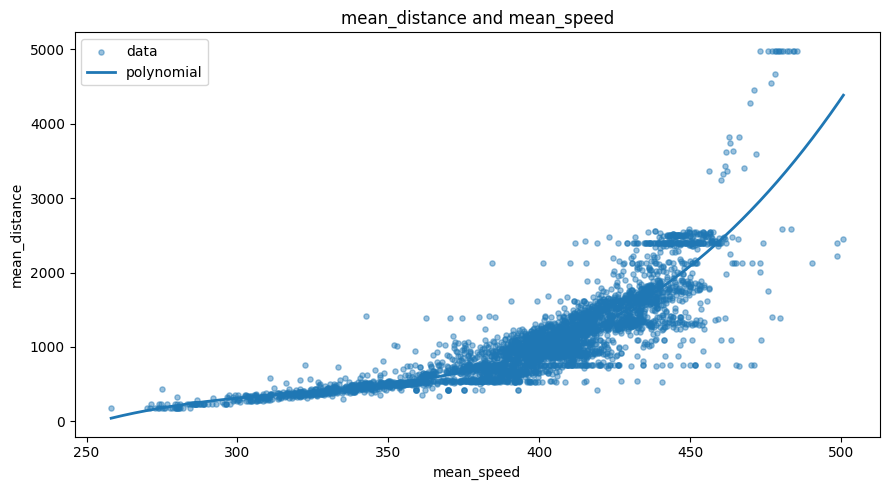

In [110]:
plt.figure(figsize=(9, 5))

plt.scatter(
    task4["mean_speed"],
    task4["mean_distance"],
    alpha=0.45,
    s=14,
    label="data"
)

plt.plot(
    x,
    y_plot,
    linewidth=2,
    label="polynomial"
)

plt.xlabel("mean_speed")
plt.ylabel("mean_distance")
plt.title("mean_distance and mean_speed")
plt.legend()
plt.tight_layout()
plt.show()

использование полиномных признаков сильно улучшело результат нашей модели

# Задание 5

Кластеризуем данные по mean_speed и n_flights

In [111]:
task5 = (
    data.groupby("tailnum")
    .agg(
        mean_speed=("speed_mph", "mean"),
        n_flights=("flight", "size")
    )
    .reset_index()
)

task5["log_n_flights"] = np.log1p(task5["n_flights"])

task5.head()

,tailnum,mean_speed,n_flights,log_n_flights
0,D942DN,381.463714,4,1.609438
1,N0EGMQ,390.577378,352,5.866468
2,N10156,385.115125,145,4.983607
3,N102UW,393.785127,48,3.891820
4,N103US,387.943443,46,3.850148


количество полетов слишком сильно разбросано по самолетом из-за чего был взят логарифм числа полетов

Оценим оптимальное число кластеров для метода KMeans

In [117]:
X = task5[["mean_speed", "log_n_flights"]]

scaler = StandardScaler()
Z = scaler.fit_transform(X)

rows = []

for k in range(2, 20):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(Z)

    rows.append({
        "k": k,
        "silhouette": silhouette_score(Z, labels)
    })

task5_score = pd.DataFrame(rows).round(4)

task5_score

,k,silhouette
0,2,0.4000
1,3,0.4604
2,4,0.3679
3,5,0.3963
4,6,0.4135
5,7,0.4271
6,8,0.4222
7,9,0.4203
8,10,0.4282
9,11,0.4266


оптимальное количество кластеров это 3

In [121]:
best_k = int(task5_score.loc[
    task5_score["silhouette"].idxmax(),
    "k"
])

model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

task5["cluster"] = model.fit_predict(Z)

Нарисуем получившееся кластеры

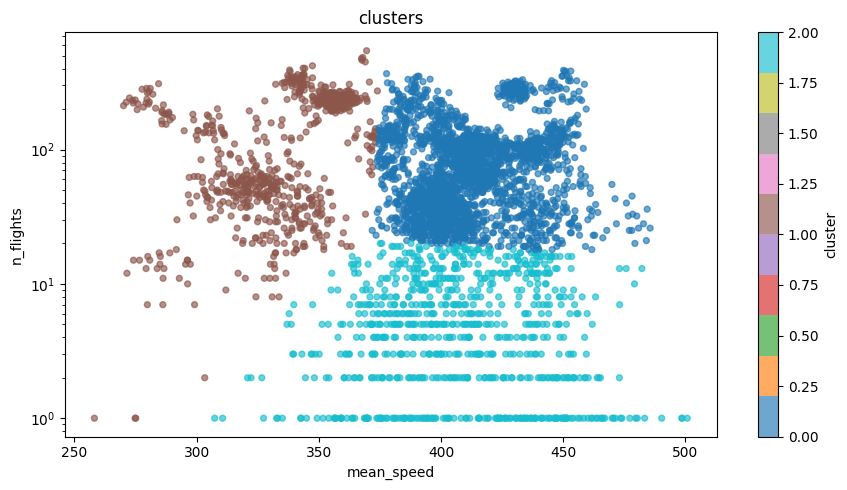

In [122]:
plt.figure(figsize=(9, 5))

scatter = plt.scatter(
    task5["mean_speed"],
    task5["n_flights"],
    c=task5["cluster"],
    alpha=0.65,
    s=18,
    cmap="tab10"
)

plt.xlabel("mean_speed")
plt.ylabel("n_flights")
plt.yscale("log")
plt.title("clusters")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

самолеты с более высокой средней скоростью и средневысоким количеством полетов скорее всего летают на больший дистанции чес самолеты с меньшей средней скоростью и таким же количеством полетов из-за меньшего влияния взлета и посадки на самолет